# Modelagem controlada do risco de defasagem

**Primeira versão exploratória** de um modelo para estimar risco de defasagem no ano seguinte. A saída deve apoiar a priorização de acompanhamento humano e oferta de apoio; não é diagnóstico, decisão automática, ranking ou julgamento de capacidade.

A base possui somente três anos e duas transições (2022 -> 2023 e 2023 -> 2024). Portanto, os resultados são preliminares e não constituem um modelo final ou uma validação temporal robusta.

## 1. Definição do problema preditivo

A pergunta é: **com informações observadas no ano `t`, quais alunos apresentam maior risco agregado de estar em defasagem no ano `t+1`?**

O target provisório é `risco_defasagem = 1` quando `Defasagem(t+1) < 0`. Antes de qualquer treino, o notebook verifica nulos, domínio do IAN e a correspondência empírica entre Defasagem e IAN. A confirmação oficial da regra de negócio continua necessária antes de uso operacional.

In [1]:
from pathlib import Path
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display

RAIZ = Path.cwd()
if not (RAIZ / 'src').exists():
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ))

from src.avaliacao_modelos import (
    avaliar_modelos_ajustados,
    plotar_curvas_precision_recall,
    plotar_matrizes_confusao,
    treinar_e_avaliar_modelos,
)
from src.modelagem import (
    COLUNAS_PROIBIDAS,
    FEATURES_CATEGORICAS,
    FEATURES_NUMERICAS,
    FEATURES_PRINCIPAIS,
    construir_modelos_iniciais,
    criar_pares_temporais,
    separar_matriz_target,
    validar_target_defasagem,
)

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

versoes = {
    'Python': platform.python_version(),
    'pandas': pd.__version__,
    'numpy': np.__version__,
    'scikit-learn': sklearn.__version__,
}
versoes

{'Python': '3.13.5',
 'pandas': '2.2.3',
 'numpy': '2.1.3',
 'scikit-learn': '1.6.1'}

## 2. Carregamento da base longitudinal

Usamos a base longitudinal já produzida pela preparação da EDA, sem sobrescrevê-la. A base transversal de 2024 não é suficiente para o desenho temporal.

In [2]:
CAMINHO_BASE = RAIZ / 'data/processed/passos_magicos_clean_eda.csv'
df = pd.read_csv(CAMINHO_BASE)
df['RA'] = df['RA'].astype(str).str.strip()

diagnostico_base = pd.DataFrame({
    'registros': df.groupby('Ano_Referencia').size(),
    'alunos_unicos': df.groupby('Ano_Referencia')['RA'].nunique(),
    'duplicados_ra_ano': [
        df.loc[df['Ano_Referencia'].eq(ano)].duplicated('RA').sum()
        for ano in sorted(df['Ano_Referencia'].unique())
    ],
})
print(f'Dimensão total: {df.shape[0]} linhas e {df.shape[1]} colunas')
print(f'Alunos únicos: {df["RA"].nunique()}')
display(diagnostico_base)

Dimensão total: 2845 linhas e 30 colunas
Alunos únicos: 1586


,registros,alunos_unicos,duplicados_ra_ano
Ano_Referencia,,,
2022,860,860,0
2023,931,931,0
2024,1054,1054,0


## 3. Validação do target

A execução é interrompida se houver target nulo, IAN fora do domínio esperado ou inconsistência na regra observada. A correspondência abaixo é uma validação estrutural da base, não confirmação oficial da semântica.

In [12]:
relatorio_target = validar_target_defasagem(df)
display(pd.Series(relatorio_target, name='resultado').to_frame())
display(pd.crosstab(df['Defasagem'], df['IAN'], margins=True))

if relatorio_target['nulos_defasagem'] > 0:
    raise ValueError('Modelagem bloqueada: há valores nulos em Defasagem.')
if relatorio_target['nulos_ian'] > 0:
    raise ValueError('Modelagem bloqueada: há valores nulos em IAN.')
if not relatorio_target['dominio_ian_valido']:
    raise ValueError('Modelagem bloqueada: o domínio do IAN é inválido.')
if relatorio_target['inconsistencias_defasagem_ian'] > 0:
    raise ValueError('Modelagem bloqueada: Defasagem e IAN são inconsistentes.')

print('Validação estrutural aprovada.')

,resultado
registros,2845
nulos_defasagem,0
nulos_ian,0
inconsistencias_defasagem_ian,0
dominio_ian_valido,True


IAN,2.5,5.0,10.0,All
Defasagem,,,,
-5,1,0,0,1
-4,5,0,0,5
-3,38,0,0,38
-2,0,382,0,382
-1,0,1253,0,1253
0,0,0,1024,1024
1,0,0,120,120
2,0,0,20,20
3,0,0,2,2


Validação estrutural aprovada.


## 4. Criação da variável de risco

A variável é criada somente na linha do ano futuro após a junção por RA:

`risco_defasagem(t+1) = 1` se `Defasagem(t+1) < 0`; caso contrário, `0`.

Nenhuma versão de Defasagem, IAN, Fase Ideal, INDE ou Pedra é usada como feature no modelo principal.

## 5. Features permitidas e proibidas

A primeira versão usa indicadores do ano anterior, fase, idade e tempo no programa. Fase e idade podem funcionar como proxies do estado corrente de defasagem; por isso sua contribuição deve ser tratada como associação preditiva e revista em análise de sensibilidade.

Gênero, instituição e escola ficam fora do modelo principal por exigirem justificativa ética específica. IPP fica fora porque não existe em 2022. Inglês fica fora devido à ausência estrutural elevada. RA é usado somente para criar pares e nunca entra na matriz de modelagem.

In [13]:
catalogo = pd.DataFrame({
    'grupo': ['permitida'] * len(FEATURES_PRINCIPAIS) + ['não permitida'] * len(COLUNAS_PROIBIDAS),
    'coluna': FEATURES_PRINCIPAIS + sorted(COLUNAS_PROIBIDAS),
})
display(catalogo)

,grupo,coluna
0,permitida,Idade
1,permitida,Tempo_no_programa
2,permitida,IAA
3,permitida,IEG
4,permitida,IPS
5,permitida,IDA
6,permitida,Nota_Matematica
7,permitida,Nota_Portugues
8,permitida,IPV
9,permitida,Fase


## 6. Construção das janelas temporais

O treino usa features de 2022 e target de 2023. O teste final usa features de 2023 e target de 2024. Não há divisão aleatória.

In [5]:
treino = criar_pares_temporais(df, ano_features=2022, ano_target=2023)
teste = criar_pares_temporais(df, ano_features=2023, ano_target=2024)

resumo_janelas = pd.DataFrame({
    'janela': ['2022→2023 (treino)', '2023→2024 (teste)'],
    'pares': [len(treino), len(teste)],
    'casos_de_risco': [treino['risco_defasagem'].sum(), teste['risco_defasagem'].sum()],
    'prevalencia_risco': [treino['risco_defasagem'].mean(), teste['risco_defasagem'].mean()],
}).set_index('janela')

alunos_em_ambas = treino['RA'].isin(teste['RA']).sum()
alunos_novos_teste = (~teste['RA'].isin(treino['RA'])).sum()
display(resumo_janelas.style.format({'prevalencia_risco': '{:.1%}'}))
print(f'Alunos em ambas as janelas: {alunos_em_ambas}')
print(f'Alunos não observados na janela de treino: {alunos_novos_teste}')

,pares,casos_de_risco,prevalencia_risco
janela,,,
2022→2023 (treino),570,362,63.5%
2023→2024 (teste),678,305,45.0%


Alunos em ambas as janelas: 434
Alunos não observados na janela de treino: 244


In [14]:
treino.head()

,RA,ano_features,ano_target,Idade,Tempo_no_programa,IAA,IEG,IPS,IDA,Nota_Matematica,Nota_Portugues,IPV,Fase,risco_defasagem
0,RA-19,2022,2023,19,0,7.9,9.5,7.5,8.0,7.0,9.0,7.000,FASE 7,1
1,RA-27,2022,2023,17,6,0.0,7.6,8.1,8.0,7.7,6.3,9.111,FASE 6,0
2,RA-32,2022,2023,16,4,8.8,5.2,8.8,6.1,5.7,3.6,7.944,FASE 6,0
3,RA-38,2022,2023,17,5,9.2,8.9,7.5,8.6,9.0,7.0,9.833,FASE 6,0
4,RA-39,2022,2023,16,5,0.0,4.8,6.9,6.9,7.7,5.1,6.111,FASE 6,0


In [15]:
teste.head()

,RA,ano_features,ano_target,Idade,Tempo_no_programa,IAA,IEG,IPS,IDA,Nota_Matematica,Nota_Portugues,IPV,Fase,risco_defasagem
0,RA-861,2023,2024,8,0,9.5,10.0,8.13,9.6,9.8,9.4,8.920,ALFA,1
1,RA-862,2023,2024,9,0,8.5,9.1,8.14,8.9,8.5,9.2,8.585,ALFA,1
2,RA-863,2023,2024,7,0,0.0,7.6,3.14,6.3,7.0,5.5,6.260,ALFA,1
3,RA-867,2023,2024,8,0,9.0,8.6,8.76,8.9,8.7,9.0,8.415,ALFA,1
4,RA-868,2023,2024,8,0,10.0,9.5,8.76,7.1,7.8,6.3,8.670,ALFA,1


## 7. Tratamento de nulos e encoding

Variáveis numéricas recebem mediana calculada somente no treino, indicador de ausência e padronização. A variável categórica Fase recebe a moda do treino e one-hot encoding com categorias desconhecidas ignoradas. Todas as transformações ficam dentro de `Pipeline`, impedindo ajuste no teste.

In [6]:
x_treino, y_treino = separar_matriz_target(treino)
x_teste, y_teste = separar_matriz_target(teste)

nulos = pd.DataFrame({
    'nulos_treino': x_treino.isna().sum(),
    'percentual_treino': x_treino.isna().mean(),
    'nulos_teste': x_teste.isna().sum(),
    'percentual_teste': x_teste.isna().mean(),
})
display(nulos.style.format({'percentual_treino': '{:.1%}', 'percentual_teste': '{:.1%}'}))

assert 'RA' not in x_treino.columns
assert set(x_treino.columns) == set(FEATURES_NUMERICAS + FEATURES_CATEGORICAS)

,nulos_treino,percentual_treino,nulos_teste,percentual_teste
Idade,0,0.0%,0,0.0%
Tempo_no_programa,0,0.0%,0,0.0%
IAA,0,0.0%,0,0.0%
IEG,0,0.0%,0,0.0%
IPS,0,0.0%,0,0.0%
IDA,0,0.0%,0,0.0%
Nota_Matematica,0,0.0%,0,0.0%
Nota_Portugues,0,0.0%,0,0.0%
IPV,0,0.0%,0,0.0%
Fase,0,0.0%,0,0.0%


## 8. Baseline e modelos iniciais

O `DummyClassifier` representa a referência baseada na prevalência. Os demais modelos são configurações iniciais conservadoras, sem busca de hiperparâmetros no teste:

- LogisticRegression;
- DecisionTreeClassifier;
- RandomForestClassifier;
- GradientBoostingClassifier.

In [16]:
modelos = construir_modelos_iniciais()
comparacao, matrizes, modelos_ajustados = treinar_e_avaliar_modelos(
    modelos, x_treino, y_treino, x_teste, y_teste
)

display(
    comparacao
    .style
    .format("{:.3f}")
    .background_gradient(
        cmap="Blues",
        subset=["recall_risco", "precision_risco", "f1_risco", "pr_auc"]
    )
    .background_gradient(
        cmap="Blues_r",
        subset=["brier_score"]
    )
)

,recall_risco,precision_risco,f1_risco,pr_auc,brier_score
modelo,,,,,
LogisticRegression,0.521,0.841,0.644,0.809,0.179
RandomForestClassifier,0.675,0.746,0.709,0.800,0.173
GradientBoostingClassifier,0.669,0.726,0.696,0.781,0.178
DecisionTreeClassifier,0.564,0.778,0.654,0.747,0.185
DummyClassifier,1.000,0.450,0.621,0.450,0.282


## 9. Matrizes de confusão e curvas precisão-recall

Falsos negativos representam alunos em risco não sinalizados. Falsos positivos representam sinalizações que exigiriam revisão humana, com possibilidade de estigma ou uso inadequado. Nenhuma matriz contém identificação individual.

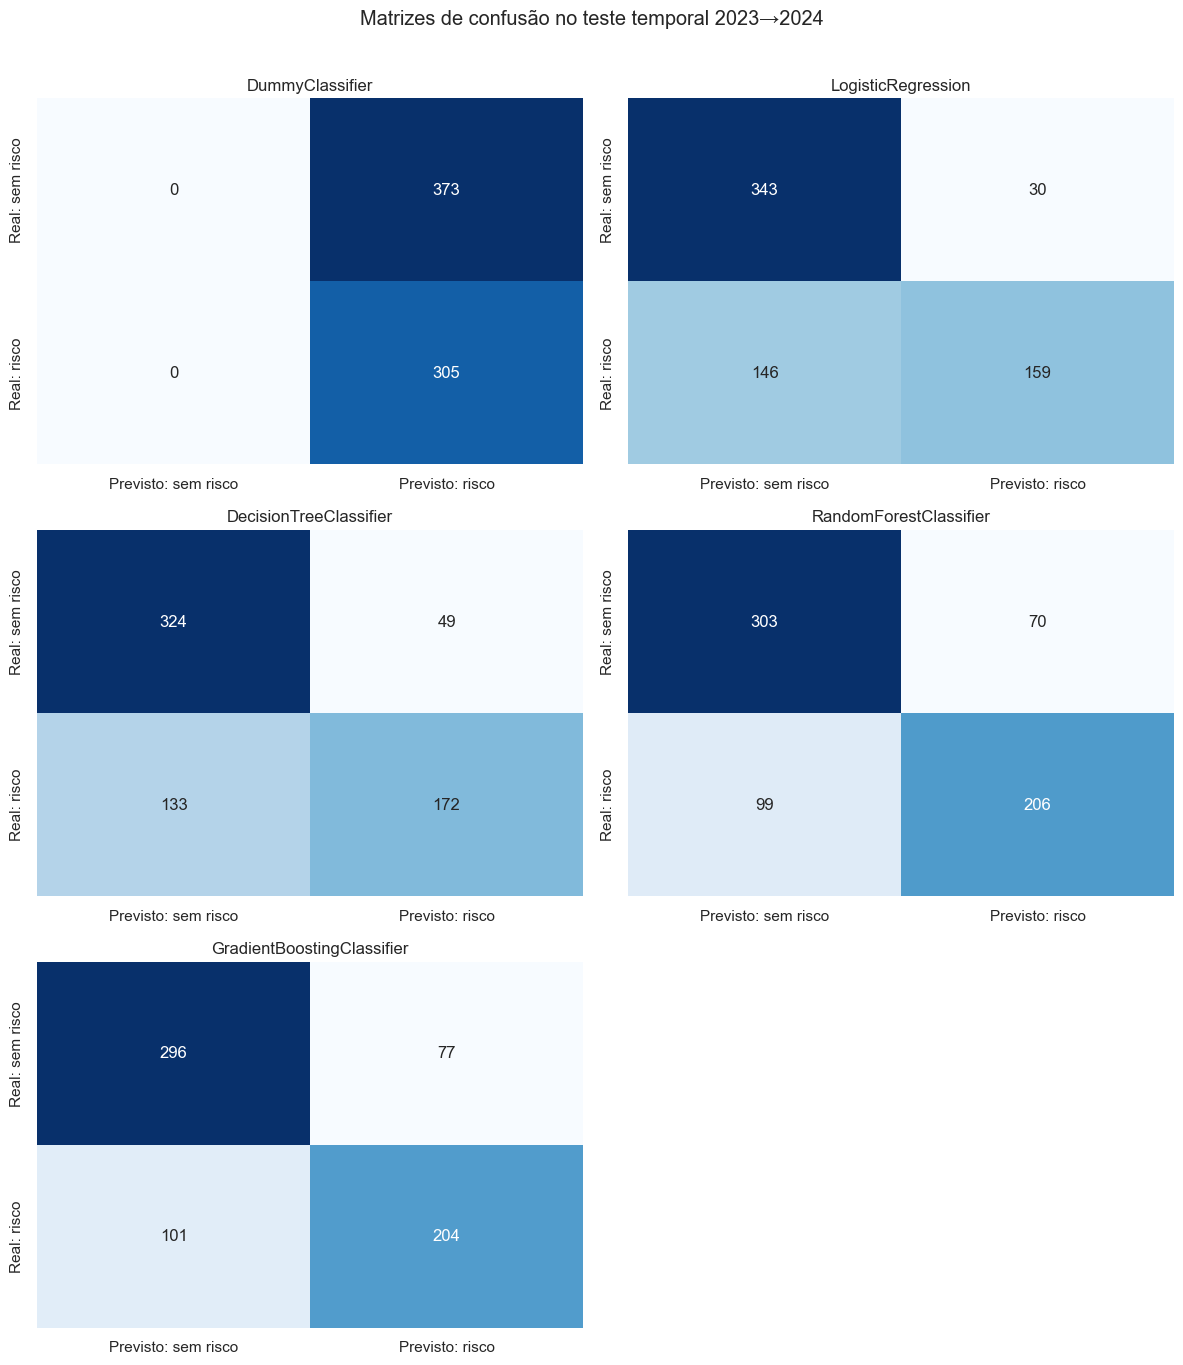

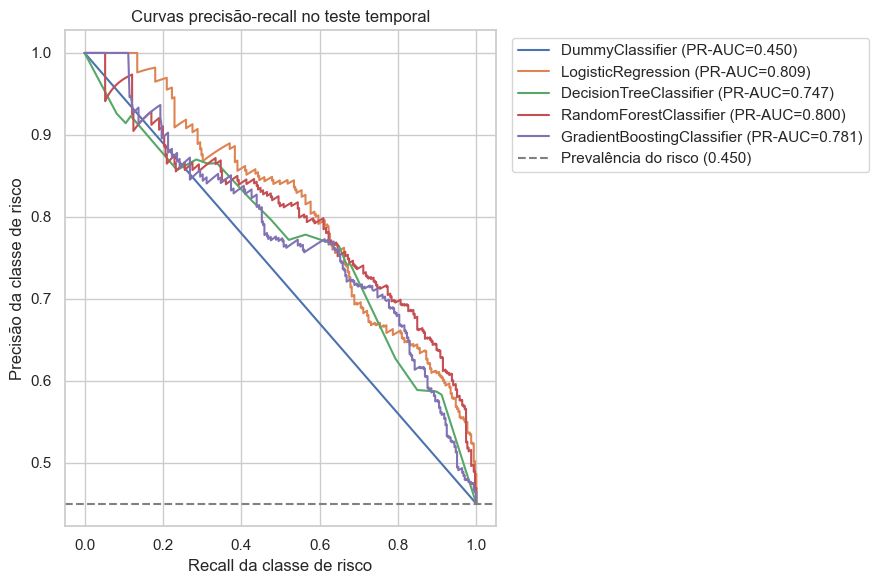

In [18]:
plotar_matrizes_confusao(matrizes)
plt.show()
plotar_curvas_precision_recall(modelos_ajustados, x_teste, y_teste)
plt.show()

## 10. Sensibilidade para alunos não observados no treino

Como parte dos alunos aparece nas duas janelas, avaliamos separadamente os registros de 2024 cujos RAs não participaram da janela 2022→2023. O RA serve apenas para construir a máscara; não é fornecido aos modelos.

In [9]:
mascara_nao_observados = ~teste['RA'].isin(treino['RA'])
comparacao_nao_observados = avaliar_modelos_ajustados(
    modelos_ajustados,
    x_teste.loc[mascara_nao_observados],
    y_teste.loc[mascara_nao_observados],
)
print(f'Amostra de sensibilidade: {mascara_nao_observados.sum()} alunos')
display(comparacao_nao_observados.style.format('{:.3f}'))

Amostra de sensibilidade: 244 alunos


,recall_risco,precision_risco,f1_risco,pr_auc,brier_score
modelo,,,,,
LogisticRegression,0.448,0.901,0.598,0.842,0.240
RandomForestClassifier,0.657,0.797,0.720,0.836,0.198
DecisionTreeClassifier,0.462,0.846,0.597,0.817,0.226
GradientBoostingClassifier,0.566,0.764,0.651,0.794,0.230
DummyClassifier,1.000,0.586,0.739,0.586,0.245


## 11. Explicabilidade global inicial

A tabela mostra os maiores coeficientes absolutos da regressão logística e as maiores importâncias dos modelos de árvore. Essas medidas descrevem o comportamento do modelo e **não demonstram causalidade**, mérito ou capacidade individual.

In [10]:
explicacoes = {}
for nome, pipeline in modelos_ajustados.items():
    if nome == 'DummyClassifier':
        continue
    nomes_features = pipeline.named_steps['preprocessamento'].get_feature_names_out()
    estimador = pipeline.named_steps['modelo']
    if hasattr(estimador, 'coef_'):
        valores = estimador.coef_[0]
        tabela = pd.DataFrame({'feature': nomes_features, 'valor': valores})
        tabela['importancia_absoluta'] = tabela['valor'].abs()
    else:
        valores = estimador.feature_importances_
        tabela = pd.DataFrame({'feature': nomes_features, 'valor': valores})
        tabela['importancia_absoluta'] = tabela['valor'].abs()
    explicacoes[nome] = tabela.nlargest(10, 'importancia_absoluta').reset_index(drop=True)

for nome, tabela in explicacoes.items():
    print(f'\n{nome}')
    display(tabela)


LogisticRegression


,feature,valor,importancia_absoluta
0,Fase_ALFA,4.274590,4.274590
1,Fase_FASE 6,-2.321300,2.321300
2,Fase_FASE 1,2.276861,2.276861
3,Idade,2.262929,2.262929
4,Fase_FASE 3,-1.810378,1.810378
5,Fase_FASE 5,-1.311251,1.311251
6,Fase_FASE 4,-1.198200,1.198200
7,IDA,-0.895736,0.895736
8,IPV,-0.693397,0.693397
9,Nota_Portugues,0.315128,0.315128



DecisionTreeClassifier


,feature,valor,importancia_absoluta
0,IPV,0.332877,0.332877
1,Idade,0.322471,0.322471
2,Fase_ALFA,0.116985,0.116985
3,Nota_Matematica,0.051412,0.051412
4,Fase_FASE 1,0.045837,0.045837
5,Nota_Portugues,0.037410,0.037410
6,Fase_FASE 3,0.036577,0.036577
7,IDA,0.020273,0.020273
8,IAA,0.019326,0.019326
9,IEG,0.016833,0.016833



RandomForestClassifier


,feature,valor,importancia_absoluta
0,IPV,0.210588,0.210588
1,Idade,0.150700,0.150700
2,IDA,0.104853,0.104853
3,Nota_Matematica,0.090237,0.090237
4,IEG,0.088528,0.088528
5,Nota_Portugues,0.081548,0.081548
6,Fase_ALFA,0.070630,0.070630
7,Fase_FASE 3,0.044071,0.044071
8,IAA,0.042114,0.042114
9,Tempo_no_programa,0.039945,0.039945



GradientBoostingClassifier


,feature,valor,importancia_absoluta
0,Idade,0.283342,0.283342
1,IPV,0.195219,0.195219
2,Fase_ALFA,0.102098,0.102098
3,Fase_FASE 3,0.084151,0.084151
4,IDA,0.053577,0.053577
5,Nota_Matematica,0.046699,0.046699
6,Fase_FASE 2,0.041812,0.041812
7,Nota_Portugues,0.039784,0.039784
8,IAA,0.027873,0.027873
9,IPS,0.027058,0.027058


## 12. Comparação e análise crítica dos resultados

A PR-AUC é a métrica principal de ordenação porque considera o desempenho da classe de risco diante da prevalência observada. Recall, precision e F1 devem ser lidos em conjunto. O limiar padrão desta execução é apenas uma referência técnica e não foi aprovado como limiar operacional.

Por esse motivo, a comparação entre modelos não deve ser interpretada apenas como uma disputa pelo maior valor agregado de métrica. Como o problema envolve sinalizar alunos em situação potencial de risco, a decisão preliminar precisa considerar também o tipo de erro mais sensível para o contexto da Passos Mágicos. Nesta etapa exploratória, o modelo mais adequado não é necessariamente aquele com melhor desempenho médio geral, mas aquele que oferece uma base mais defensável para investigar e reduzir falsos negativos.

### Escolha preliminar do modelo

Embora a Regressão Logística tenha apresentado a maior PR-AUC preliminar, o modelo escolhido para continuidade da análise será o **Random Forest**, pois ele apresentou maior **recall da classe de risco**.

Essa escolha é coerente com o objetivo do projeto: identificar alunos com maior probabilidade de entrar ou permanecer em defasagem para apoiar ações preventivas da Passos Mágicos. Nesse contexto, um falso negativo é mais crítico do que um falso positivo, pois representa um aluno em risco que não seria sinalizado para acompanhamento.

A Regressão Logística teve PR-AUC ligeiramente superior, mas sinalizou uma proporção menor dos alunos em risco. Já o Random Forest apresentou melhor equilíbrio para uma primeira versão exploratória, com maior capacidade de capturar alunos vulneráveis, ainda que com alguma perda de precisão.

Portanto, o Random Forest será tratado como **modelo candidato principal para continuidade**, não como modelo final. Antes de qualquer uso operacional, ainda será necessário realizar calibração de probabilidades, ajuste de limiar, análise de falsos negativos, validação externa e revisão ética das variáveis utilizadas.

In [19]:
modelos_reais = comparacao.drop(index='DummyClassifier')
melhor_nome = modelos_reais['pr_auc'].idxmax()
melhor = modelos_reais.loc[melhor_nome]
baseline = comparacao.loc['DummyClassifier']
ganho_pr_auc = melhor['pr_auc'] - baseline['pr_auc']

print(f'Melhor PR-AUC preliminar: {melhor_nome} ({melhor["pr_auc"]:.3f}).')
print(f'Ganho absoluto sobre o baseline: {ganho_pr_auc:.3f}.')
print(f'Recall de risco: {melhor["recall_risco"]:.3f}.')
print(f'Precisão de risco: {melhor["precision_risco"]:.3f}.')
print(f'F1 de risco: {melhor["f1_risco"]:.3f}.')

if ganho_pr_auc <= 0:
    print('Os modelos não superaram o baseline em PR-AUC; não há evidência para avanço operacional.')
else:
    print('Há sinal preditivo preliminar, mas ele precisa de novas safras, calibração e validação externa.')

Melhor PR-AUC preliminar: LogisticRegression (0.809).
Ganho absoluto sobre o baseline: 0.359.
Recall de risco: 0.521.
Precisão de risco: 0.841.
F1 de risco: 0.644.
Há sinal preditivo preliminar, mas ele precisa de novas safras, calibração e validação externa.


In [20]:
modelo_escolhido = comparacao.loc["RandomForestClassifier"]

print("Modelo escolhido para continuidade: RandomForestClassifier.")
print(f"PR-AUC: {modelo_escolhido['pr_auc']:.3f}.")
print(f"Recall de risco: {modelo_escolhido['recall_risco']:.3f}.")
print(f"Precisão de risco: {modelo_escolhido['precision_risco']:.3f}.")
print(f"F1 de risco: {modelo_escolhido['f1_risco']:.3f}.")
print(
    "A escolha prioriza recall porque, neste problema, deixar de sinalizar "
    "um aluno em risco é mais crítico do que gerar uma sinalização adicional "
    "para revisão humana."
)
print(
    "O modelo ainda é preliminar e precisa de calibração, ajuste de limiar, "
    "validação externa e análise ética antes de qualquer uso operacional."
)

Modelo escolhido para continuidade: RandomForestClassifier.
PR-AUC: 0.800.
Recall de risco: 0.675.
Precisão de risco: 0.746.
F1 de risco: 0.709.
A escolha prioriza recall porque, neste problema, deixar de sinalizar um aluno em risco é mais crítico do que gerar uma sinalização adicional para revisão humana.
O modelo ainda é preliminar e precisa de calibração, ajuste de limiar, validação externa e análise ética antes de qualquer uso operacional.


## 13. Limitações

1. Há somente três anos e duas transições; uma única janela fica disponível para teste temporal.
2. A prevalência do risco muda entre treino e teste, indicando mudança de população, processo ou distribuição.
3. Parte dos alunos aparece em treino e teste. A análise de sensibilidade para não observados reduz, mas não elimina, essa limitação.
4. A regra de Defasagem foi validada empiricamente.
5. Fase e idade podem aproximar o estado corrente de defasagem.
6. Não houve otimização de limiar, calibração formal, intervalos de incerteza ou validação externa.
7. Importâncias e coeficientes são explicações do modelo, não efeitos causais. 

**Conclusão:** esta execução produz somente evidência preliminar para pesquisa e desenvolvimento. Nenhum dos estimadores é declarado modelo final.